# Task
Perform sentiment analysis on the "user_reviews.csv" dataset using XGBoost. The sentiment column is "Sentiment" and the text column is "Translated_Review". Remove rows with 'nan' in either of these columns during preprocessing. Split the data into 70% training and 30% testing sets. Optimize the XGBoost model for best accuracy.

## Load the dataset

### Subtask:
Load the `user_reviews.csv` file into a pandas DataFrame.


**Reasoning**:
Load the data into a pandas DataFrame and display the head and info to understand the data.



In [13]:
import pandas as pd

df = pd.read_csv('user_reviews.csv')
display(df.head())
display(df.info())

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


None

## Preprocess the data

### Subtask:
Handle missing values by removing rows where `Translated_Review` or `Sentiment` are NaN. Convert the `Sentiment` column to a numerical format (e.g., using one-hot encoding or label encoding).


**Reasoning**:
Handle missing values and encode the sentiment column as requested in the instructions.



In [14]:
df_cleaned = df.dropna(subset=['Translated_Review', 'Sentiment']).copy()

sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df_cleaned['Sentiment_Encoded'] = df_cleaned['Sentiment'].map(sentiment_mapping)

display(df_cleaned.head())
display(df_cleaned.info())

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Sentiment_Encoded
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,2
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,2
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,2
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,2
5,10 Best Foods for You,Best way,Positive,1.00,0.300000,2


<class 'pandas.DataFrame'>
Index: 37427 entries, 0 to 64230
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     37427 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37427 non-null  str    
 3   Sentiment_Polarity      37427 non-null  float64
 4   Sentiment_Subjectivity  37427 non-null  float64
 5   Sentiment_Encoded       37427 non-null  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 2.0 MB


None

## Split the data

### Subtask:
Split the data into training and testing sets (70% training, 30% testing).


**Reasoning**:
Split the cleaned data into training and testing sets for the sentiment analysis model.



In [15]:
from sklearn.model_selection import train_test_split

X = df_cleaned['Translated_Review']
y = df_cleaned['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\nTesting set shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set shape:
X_train: (26198,)
y_train: (26198,)

Testing set shape:
X_test: (11229,)
y_test: (11229,)


## Vectorize the text data

### Subtask:
Convert the `Translated_Review` text data into numerical features using a technique like TF-IDF.


**Reasoning**:
Convert the text data into numerical features using TF-IDF.



In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF transformed training data shape:", X_train_tfidf.shape)
print("TF-IDF transformed testing data shape:", X_test_tfidf.shape)

TF-IDF transformed training data shape: (26198, 18263)
TF-IDF transformed testing data shape: (11229, 18263)


## Train the xgboost model

### Subtask:
Train an XGBoost classifier on the training data.


**Reasoning**:
Train an XGBoost classifier on the TF-IDF transformed training data.



**Reasoning**:
The error indicates that the target variable `y_train` is not in the expected numerical format for XGBoost. It should be using the encoded sentiment values. I will use the encoded sentiment column for training.



In [17]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss')
xgb_model.fit(X_train_tfidf, df_cleaned.loc[y_train.index, 'Sentiment_Encoded'])

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

## Evaluate the model

### Subtask:
Evaluate the trained model on the testing data using appropriate metrics like accuracy, precision, recall, and F1-score.


**Reasoning**:
Evaluate the trained XGBoost model on the testing data using accuracy, precision, recall, and F1-score.



In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = xgb_model.predict(X_test_tfidf)

accuracy = accuracy_score(df_cleaned.loc[y_test.index, 'Sentiment_Encoded'], y_pred)
precision = precision_score(df_cleaned.loc[y_test.index, 'Sentiment_Encoded'], y_pred, average='weighted')
recall = recall_score(df_cleaned.loc[y_test.index, 'Sentiment_Encoded'], y_pred, average='weighted')
f1 = f1_score(df_cleaned.loc[y_test.index, 'Sentiment_Encoded'], y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.8942025113545284
Precision: 0.8979090320276664
Recall: 0.8942025113545284
F1-score: 0.8931103186977397


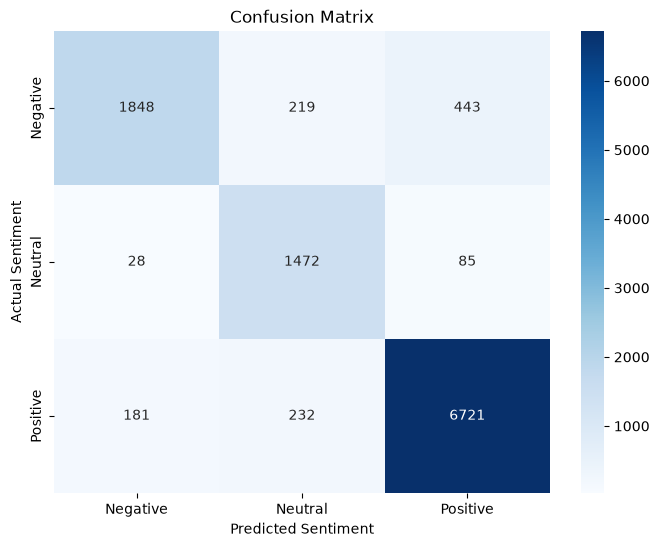

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Calculate the confusion matrix
cm = confusion_matrix(df_cleaned.loc[y_test.index, 'Sentiment_Encoded'], y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_mapping.keys(), yticklabels=sentiment_mapping.keys())
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix')
plt.show()

In [20]:
import joblib

# Save the trained model
joblib.dump(xgb_model, 'sentiment_model.pkl')

print("Model saved successfully!")

Model saved successfully!
